# Exploratory Data Analysis (EDA)
## Madrid Rental Housing Dataset

---

**Dataset:** Houses for rent in Madrid (2,089 properties)

**Source:** idealista.com

**Project:** Group Assignment - Machine Learning I

---

### Analysis Steps:

1. **Data Loading & Initial Exploration**
   - Dataset overview
   - Variable types and summary statistics
   - Missing values assessment

2. **Data Quality Issues**
   - Outlier detection
   - Data irregularities

3. **Data Cleaning**
   - Missing values handling
   - Outlier treatment

4. **Deep Dive Analysis**
   - Rent distribution by district
   - Correlation analysis
   - Outlier identification
   - Relationship exploration

5. **Feature Engineering (To Be Discussed)**
   - Potential new features for modeling

---

## 1. Data Loading & Initial Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('Houses for rent in Madrid.xlsx')
df.shape

(2089, 15)

In [3]:
df.head()

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   str    
 2   Address       2089 non-null   str    
 3   Number        747 non-null    str    
 4   Area          2085 non-null   str    
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 341.9 KB


In [5]:
proportions = df.isna().sum()/len(df)*100
proportions.sort_values(ascending=False)

#ISSUE: Number has 64% missing values (we must drop it)

Number          64.241264
Outer            7.754907
Floor            6.749641
Elevator         6.366683
Bedrooms         4.260412
Area             0.191479
Id               0.000000
District         0.000000
Address          0.000000
Rent             0.000000
Sq.Mt            0.000000
Penthouse        0.000000
Cottage          0.000000
Duplex           0.000000
Semidetached     0.000000
dtype: float64

In [6]:
#Summary Statistics for numerical values
df[['Rent', 'Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached']].describe()

,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
count,2089.000000,2000.000000,2089.000000,1948.000000,1927.000000,1956.000000,2089.000000,2089.000000,2089.000000,2089.000000
mean,1932.249402,2.483000,128.919579,25.662731,0.867151,0.880879,0.080900,0.042125,0.030637,0.013404
std,1495.474485,1.305206,115.745014,975.065350,0.339500,0.324013,0.272747,0.200923,0.172373,0.115023
min,450.000000,0.000000,15.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,950.000000,2.000000,65.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1400.000000,2.000000,90.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,2500.000000,3.000000,147.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,16000.000000,8.000000,1250.000000,43039.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


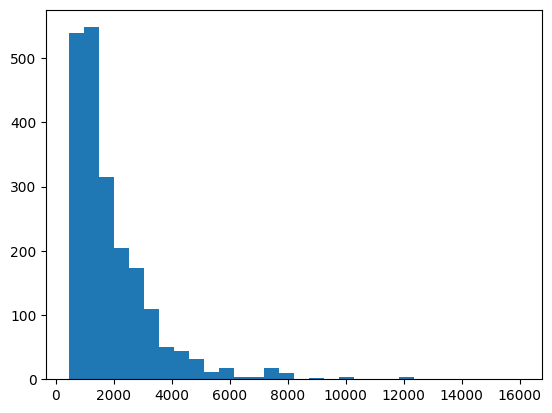

In [7]:
#Plotting rent's distribution
plt.hist(df.Rent, bins=30)
plt.show()

#We are dealing with a right-skewed target variable

In [8]:
#Which districts have the most properties?

df.groupby('District')['Id'].count().sort_values(ascending=False).head(5)

District
Salamanca    313
Centro       280
Chamartín    215
Chamberí     195
Moncloa      161
Name: Id, dtype: int64

## Data Quality Issues

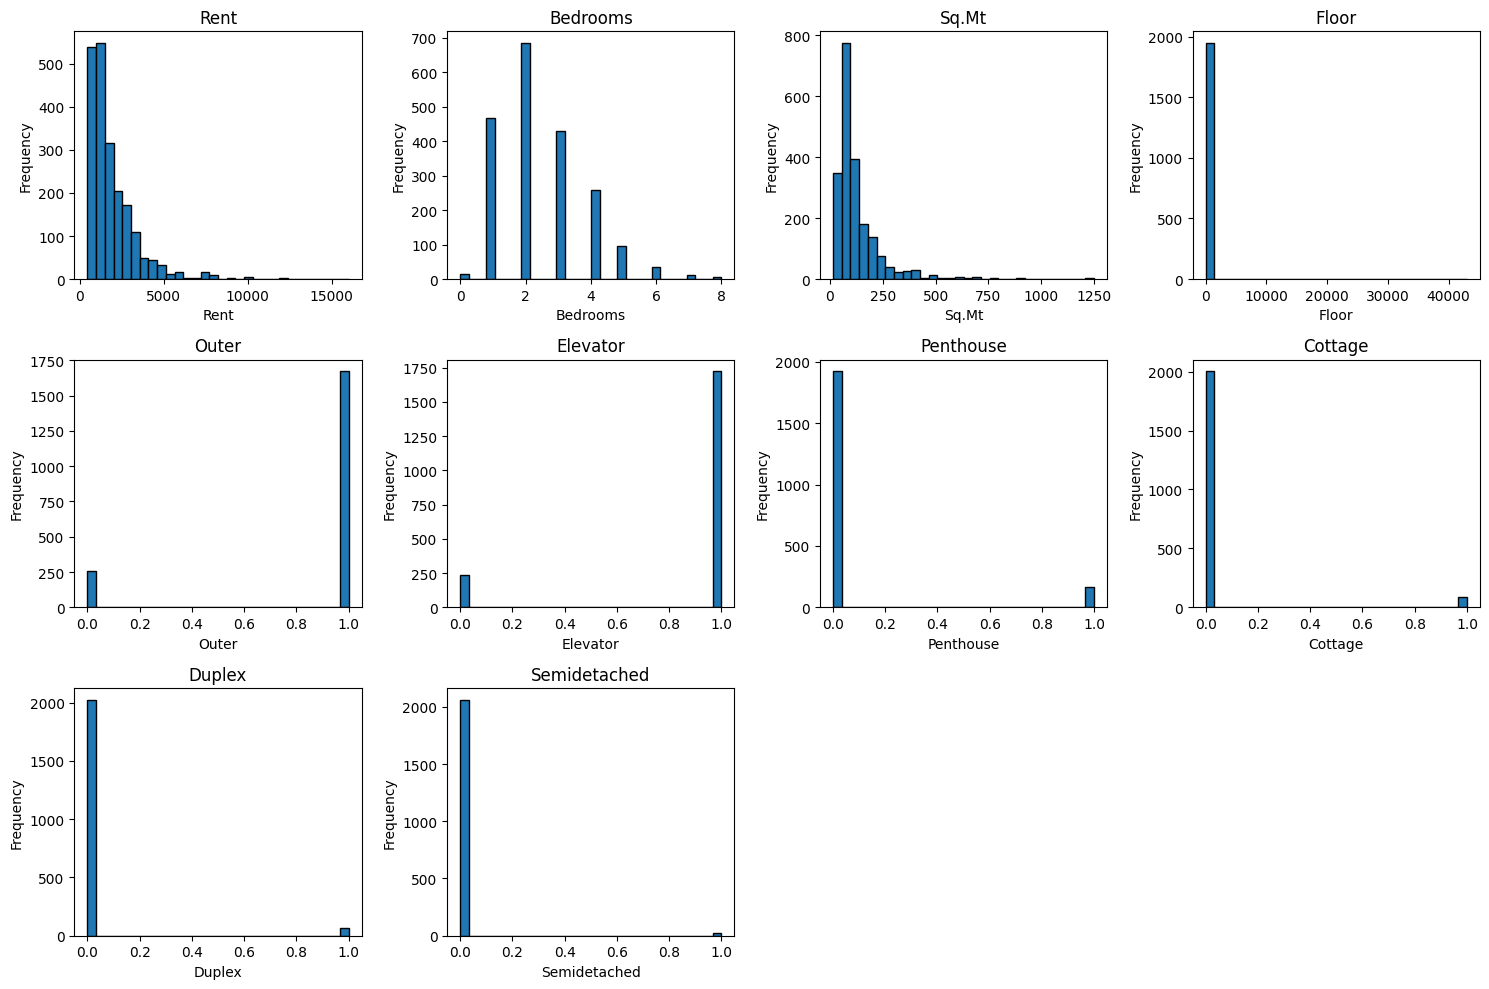

In [9]:
#Check if there are any irregularities with numerical columns

# Get numerical columns (excluding Id)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col != 'Id']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))
axes = axes.flatten()

# Plot each numerical column
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide extra subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

If we look closer, the Floor column seems to have an outlier, let's dive deeper into that:

In [10]:
df.Floor.describe()
#We have an outlier that must have been a typo error. We will fix it.

count     1948.000000
mean        25.662731
std        975.065350
min         -1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max      43039.000000
Name: Floor, dtype: float64

## Handling Missing Values

In [11]:
#Dropping Number column, as it is also meaningless for segmentation

df = df.drop(columns='Number')

df.columns

Index(['Id', 'District', 'Address', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt',
       'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex',
       'Semidetached'],
      dtype='str')

In [12]:
df.isna().sum()

Id                0
District          0
Address           0
Area              4
Rent              0
Bedrooms         89
Sq.Mt             0
Floor           141
Outer           162
Elevator        133
Penthouse         0
Cottage           0
Duplex            0
Semidetached      0
dtype: int64

### Next steps for missing values:
1. Area: drop rows, it's only 0.2% of the dataset. We don't drop the feature because Area is important as location matters for clustering similar houses.
2. Bedrooms: median imputation as it is discrete numerical value and it has a clear central tendency. The median keeps the distribution better than the mean.
3. Floor: median imputation.
4. Outer/Elevator: mode imputation as these are binary features. These values have over 80% with value = 1, so with the mode we preserve the dominance.

In [13]:
# Area
print(f"Before dropping Area nulls: {len(df)} rows")
df = df.dropna(subset=['Area'])
print(f"After dropping Area nulls: {len(df)} rows")

# Floor
# Fix the outlier (43,039 is clearly a data error)
print(f"\nFloor max before fix: {df['Floor'].max()}")
df.loc[df['Floor'] > 100, 'Floor'] = None  # Treat as missing
print(f"Floor max after fix: {df['Floor'].max()}")

# Impute Floor with median
floor_median = df['Floor'].median()
df['Floor'] = df['Floor'].fillna(floor_median)
print(f"Floor missing after imputation: {df['Floor'].isna().sum()}")

# Bedrooms
bedrooms_median = df['Bedrooms'].median()
df['Bedrooms'] = df['Bedrooms'].fillna(bedrooms_median)
print(f"\nBedrooms missing after imputation: {df['Bedrooms'].isna().sum()}")

# Outer
outer_mode = df['Outer'].mode()[0]
df['Outer'] = df['Outer'].fillna(outer_mode)
print(f"Outer missing after imputation: {df['Outer'].isna().sum()}")

# Elevator
elevator_mode = df['Elevator'].mode()[0]
df['Elevator'] = df['Elevator'].fillna(elevator_mode)
print(f"Elevator missing after imputation: {df['Elevator'].isna().sum()}")

# Final check
print(df.isna().sum())
print(f"\nFinal dataset size: {df.shape}")

Before dropping Area nulls: 2089 rows
After dropping Area nulls: 2085 rows

Floor max before fix: 43039.0
Floor max after fix: 29.0
Floor missing after imputation: 0

Bedrooms missing after imputation: 0
Outer missing after imputation: 0
Elevator missing after imputation: 0
Id              0
District        0
Address         0
Area            0
Rent            0
Bedrooms        0
Sq.Mt           0
Floor           0
Outer           0
Elevator        0
Penthouse       0
Cottage         0
Duplex          0
Semidetached    0
dtype: int64

Final dataset size: (2085, 14)


## Deep Dive Analysis

                      mean  median  count
District                                 
Moncloa            2787.26  2300.0    161
Salamanca          2780.58  2500.0    313
Retiro             2311.88  1700.0     80
Hortaleza          2298.25  1600.0    118
Chamartín          2156.08  1725.0    215
Chamberí           2107.40  1699.0    195
Centro             1821.30  1450.0    280
Ciudad Lineal      1562.79  1287.5    100
Fuencarral         1528.21  1325.0    112
Tetuán             1402.57  1070.0    146
Arganzuela         1209.42  1300.0     55
Barajas            1110.91  1150.0     22
San Blás           1074.15   950.0     60
Moratalaz           928.67   800.0     15
Villa de Vallecas   857.41   750.0     29
Latina              854.18   832.5     38
Usera               820.68   780.0     22
Carabanchel         756.92   700.0     53
Puente Vallecas     741.28   700.0     43
Vicálvaro           727.50   712.5     28


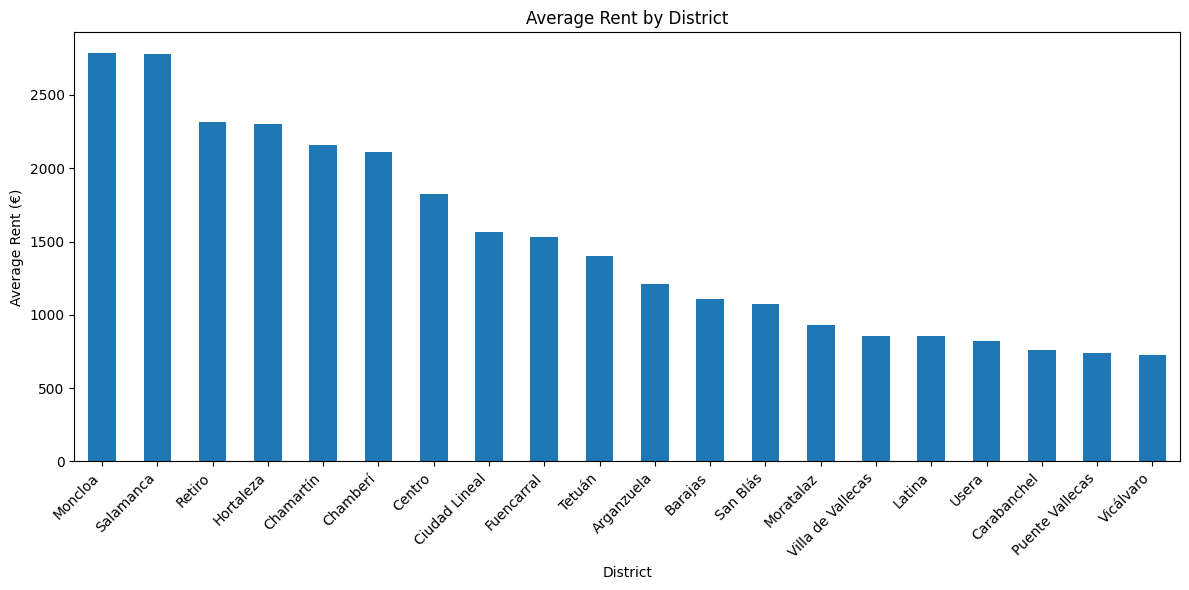

In [14]:
# Rent by district
# Average rent by district
district_rent = df.groupby('District')['Rent'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)
print(district_rent)

# Visualize
plt.figure(figsize=(12, 6))
df.groupby('District')['Rent'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Rent by District')
plt.ylabel('Average Rent (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Rent            1.000000
Sq.Mt           0.825984
Bedrooms        0.620842
Cottage         0.380159
Elevator        0.205385
Outer           0.173111
Semidetached    0.116831
Floor           0.111081
Penthouse       0.095490
Duplex          0.039418
Name: Rent, dtype: float64


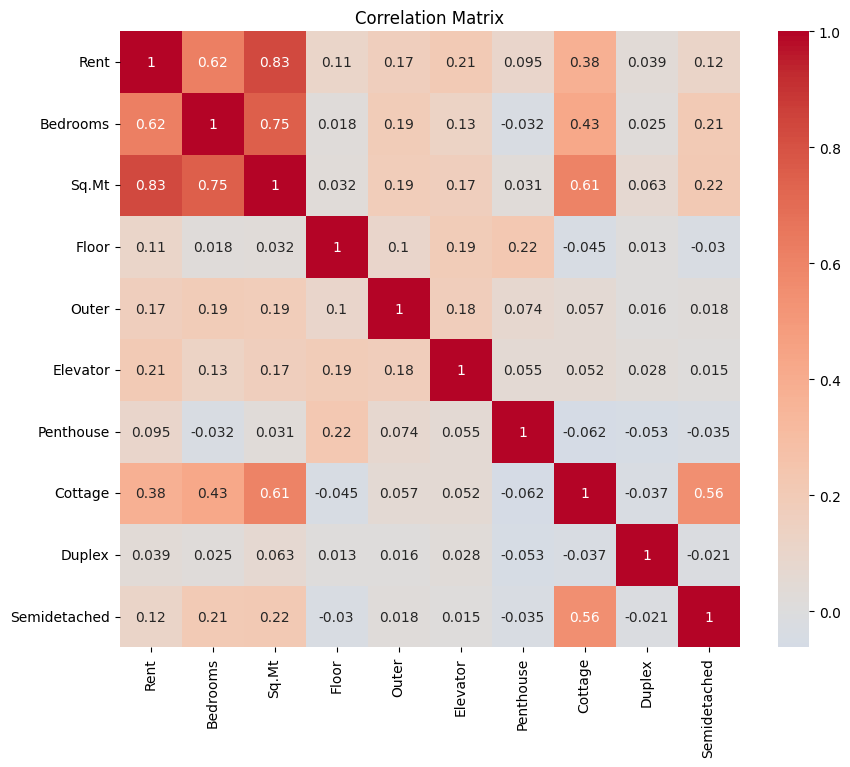

In [15]:
#What drives rent?
# Select numerical columns for correlation
corr_cols = ['Rent', 'Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 
             'Penthouse', 'Cottage', 'Duplex', 'Semidetached']
correlation = df[corr_cols].corr()

# Show correlation with Rent
print(correlation['Rent'].sort_values(ascending=False))

# Heatmap (optional)
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

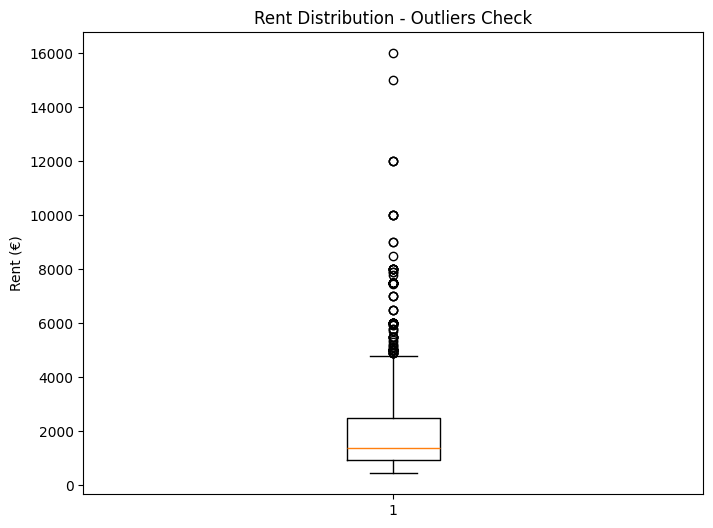


Outliers found: 94 properties
Outlier threshold: < -1375 or > 4825

Outlier examples:
       District                       Area   Rent  Bedrooms  Sq.Mt
191  Fuencarral             Fuentelarreina   6000       5.0    600
215   Hortaleza                   Canillas   4900       5.0    300
230   Hortaleza  Valdebebas - Valdefuentes   5500       5.0    600
247   Hortaleza        Conde Orgaz-Piovera  10000       6.0    600
248   Hortaleza        Conde Orgaz-Piovera   5700       6.0    325


In [16]:
# Box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df['Rent'])
plt.title('Rent Distribution - Outliers Check')
plt.ylabel('Rent (€)')
plt.show()

# Identify outliers (IQR method)
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print(f"\nOutliers found: {len(outliers)} properties")
print(f"Outlier threshold: < {lower_bound:.0f} or > {upper_bound:.0f}")
print(f"\nOutlier examples:\n{outliers[['District', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt']].head()}")

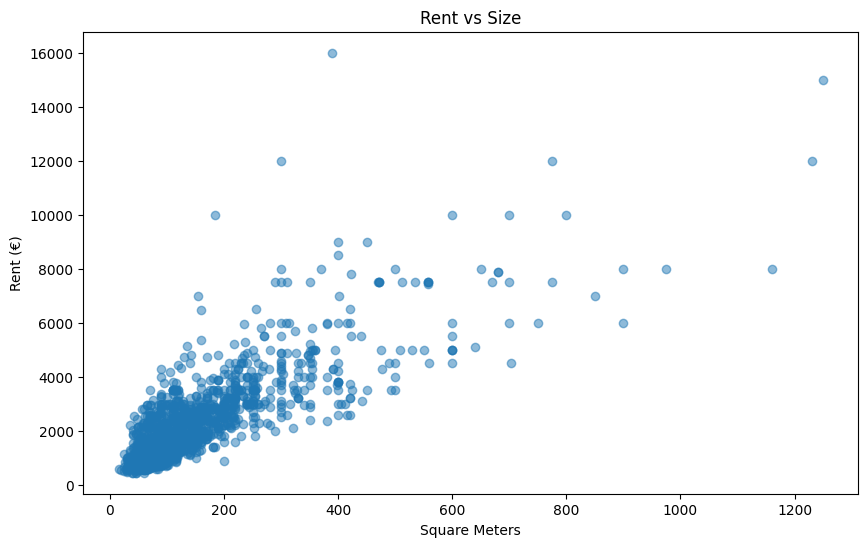

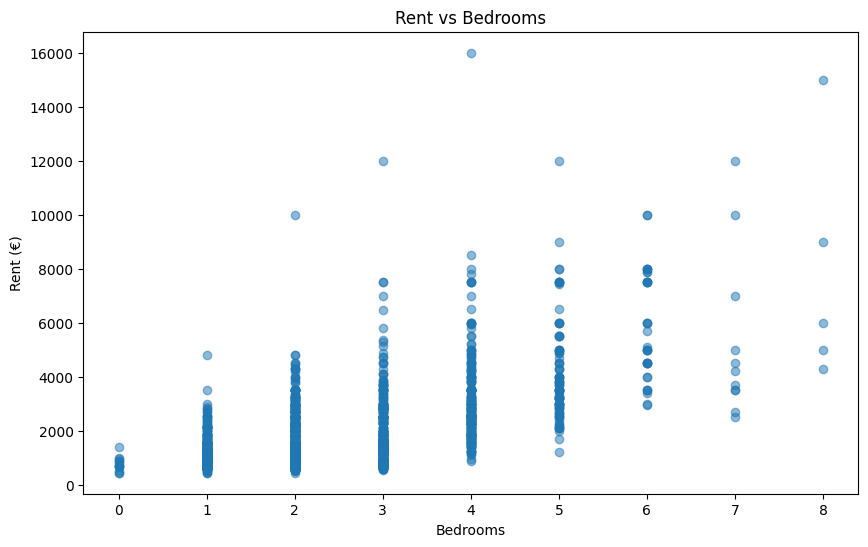

In [17]:
# Rent vs Sq.Mt
plt.figure(figsize=(10, 6))
plt.scatter(df['Sq.Mt'], df['Rent'], alpha=0.5)
plt.xlabel('Square Meters')
plt.ylabel('Rent (€)')
plt.title('Rent vs Size')
plt.show()

# Rent vs Bedrooms
plt.figure(figsize=(10, 6))
plt.scatter(df['Bedrooms'], df['Rent'], alpha=0.5)
plt.xlabel('Bedrooms')
plt.ylabel('Rent (€)')
plt.title('Rent vs Bedrooms')
plt.show()

## Save new cleaned excel file to desktop

In [18]:
# Export cleaned dataset to Excel
df.to_excel('HousesMadridClean.xlsx', index=False)
print(f"✓ Cleaned dataset exported successfully!")
print(f"✓ Rows: {len(df)}")
print(f"✓ Columns: {len(df.columns)}")
print(f"✓ File: HousesMadridClean.xlsx")

✓ Cleaned dataset exported successfully!
✓ Rows: 2085
✓ Columns: 14
✓ File: HousesMadridClean.xlsx
